---
author: Sachin Abeywardana
badges: true
branch: master
categories:
- Deep Learning
- Loss Functions
date: '2025-08-17'
description: ""
image: ../images/image_segmentation.png
title: "Image Segmentation with Deep Learning"
toc: true
format:
  html:
    code-fold: true
---

## Introduction

- We will walk through the UNet architecture.
- Data augmentation techniques for image segmentation.
- Loss functions for image segmentation.

The full code is available on [Kaggle](https://www.kaggle.com/code/sachin/trimap-segmentation). Please upvote if you find it useful. The corresponding wandb run can be found [here](https://wandb.ai/sachinruk/trimap-segmentation/runs/bk7wnzmj).

As usual I will talk structure this blog into three sections:
1. Data, and how to prepare it for training.
2. Model, and how we ingest the inputs to fit the outputs.
3. Loss functions and training; how we optimize the model to fit the data.



## Data
We will use the [Trimap Segmentation Dataset](https://www.kaggle.com/datasets/zippyz/cats-and-dogs-breeds-classification-oxford-dataset) for this blog. The dataset is a collection of images with corresponding trimap annotations. A trimap is a three-class segmentation map that indicates the foreground, background, and unknown regions of an image.

In this particular case, the trimap is used to segment images of cats and dogs into three classes. <TODO show image of trimap>

As is the case with any image task, we use augmentation to increase the size of our dataset and improve the model's generalization. Each input image contains a corresponding trimap annotation. 

However, care must be taken to ensure that the augmentation applied to the input image is also applied to the trimap annotation. This is crucial for maintaining the integrity of the segmentation task. The following two functions within the `Dataset` class is used to transform the image and the mask.
```python
    def _apply_with_seed(
        self, pil_img: Image.Image, transform: transforms.Compose, seed: int
    ) -> torch.Tensor:
        """Utility: set RNG seed, apply transform, reset not needed."""
        if transform is None:
            return pil_img
        random_state = random.getstate()
        torch_state = torch.random.get_rng_state()
        random.seed(seed)
        torch.manual_seed(seed)
        out = transform(pil_img)
        random.setstate(random_state)
        torch.random.set_rng_state(torch_state)
        return out

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        img = Image.open(self.image_paths[idx]).convert("RGB")
        mask = transforms.functional.pil_to_tensor(
            Image.open(self.mask_paths[idx]).convert("L")
        ) - 1 # 1-channel and the image itself is {1, 2, 3}. Convert to {0, 1, 2}

        seed = torch.randint(0, 2**32, ()).item()

        # 1) apply *shared* geometric transform
        img = self._apply_with_seed(img, self.image_transform, seed)
        mask = self._apply_with_seed(mask, self.mask_transform, seed)

        return img, mask.long().squeeze()
```
There are two key points to note here:
1. The `_apply_with_seed` function ensures that the same random seed is used for both the image and the mask transformations. This guarantees that any random transformations (like rotations, flips, etc.) are applied consistently to both the image and its corresponding mask.
2. The `_apply_with_seed` function also resets the random state after applying the transformation. This is important to prevent unintended side effects on other parts of the code that rely on random number generation. For instance, dropout layers in neural networks use random number generation, and we want to ensure that their behavior is not affected by the transformations applied to the images and masks.

## Model

### Encoder

We will use the UNet architecture for this task. The UNet is a convolutional neural network architecture that is widely used for image segmentation tasks. It consists of an encoder-decoder structure with skip connections that help preserve spatial information. The following is a walkthrough of how it was constructed.

In terms of the base model, we leverage the Timm library to load up a preferred backbone. In this case, we use a MobileNetv4 architecture, but the methods are general enough to accommodate other backbones as well. In order to get the base encoder, we simply need to do the following:
```python
encoder = timm.create_model(
    model_name,
    features_only=True,
    out_indices=out_indices,
    pretrained=pretrained,
)
```
In this case, out_indicies are the layers from which we want to extract features. For MobileNetv4, we use `[0, 1, 2, 3, 4]` to get the feature maps at different resolutions. If we were to inspect the shapes of these feature maps, we would see the following:
```python
>>> x = torch.randn(2, 3, 256, 256)
>>> features = encoder(x)
>>> [f.shape for f in features] 
[torch.Size([2, 32, 128, 128]),
 torch.Size([2, 48, 64, 64]),
 torch.Size([2, 80, 32, 32]),
 torch.Size([2, 160, 16, 16]),
 torch.Size([2, 960, 8, 8])]
```
It is worth reiterating that unlike a classification head, we get a list of feature maps at different resolutions. This is crucial for the UNet architecture, as we will be using these feature maps in the decoder part of the network. Also note that the above channels are specific to MobileNetv4. Other backbones will have different channel sizes. Luckily, `Timm` abstracts this away for us by providing us `encoder.feature_info.channels()`.


### Decoder - Upsampling

The first part of the mystery is how do we upsample the feature maps. Keep in mind that we need to get back to the original image size since we are doing pixel-wise classification segmentation. Taking this specific case of MobileNetv4, we start with a feature map of size `[batch_size, 960, 8, 8]` and need to get back to `[batch_size, num_classes, 256, 256]`.

We need to increase the spatial dimensions. This is done by using a few `UpBlock`s shown below:
```python
class UpBlock(nn.Module):
    """Upsample → concat skip → double conv."""

    def __init__(self, in_ch: int, skip_ch: int, out_ch: int):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.conv1 = ConvNormAct(out_ch + skip_ch, out_ch, kernel_size=3)
        self.conv2 = ConvNormAct(out_ch, out_ch, kernel_size=3)

    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        x = self.up(x)
        # handle odd input sizes
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        x = torch.cat([x, skip], dim=1)  # (B, in_ch + skip_ch, H, W)
        x = self.conv1(x)
        x = self.conv2(x)
        return x
```
In the above code, the only component that upsamples the feature map is the `ConvTranspose2d` layer. Even here it is due to the `kernel_size=2` and `stride=2` parameters. This effectively doubles the spatial dimensions of the input feature map. `ConvNormAct` is simply a combination of `Conv2d`, `BatchNorm2d`, and `ReLU` activation and helps remove boxy artifacts that are common with transpose convolutions.

### Decoder - Skip Connections

````python
class UNet(nn.Module):
    """
    UNet with a timm backbone.
    • encoder_name – any model that supports features_only=True (MobileNet-V4, V3, V2, ResNet, ConvNeXt…)
    • num_classes   – number of output channels (1 for a single-channel mask)
    """
    def __init__(
        self,
        encoder: nn.Module,
        decoder_channels: list[int],
        num_classes: int,
    ):
        super().__init__()

        # ----- Encoder ------------------------------------------------------
        self.encoder = encoder
        enc_chs = self.encoder.feature_info.channels() # list of channel dimensions

        # ----- Bridge (bottom of the “U”) -----------------------------------
        self.center = nn.Sequential(
            ConvNormAct(enc_chs[-1], enc_chs[-1], kernel_size=3),
            ConvNormAct(
                enc_chs[-1], decoder_channels[0], kernel_size=3
            ),  # shrink to decoder’s first width
        )

        # ----- Decoder ------------------------------------------------------
        # You can tune this list – it controls decoder widths at each scale
        decoder_channels = decoder_channels

        self.up_blocks = nn.ModuleList()
        for i in range(
            len(decoder_channels) - 1
        ):  # four up-sampling steps (bring C5 → C1 resolution)
            self.up_blocks.append(
                UpBlock(decoder_channels[i], enc_chs[-(i + 2)], decoder_channels[i + 1])
            )

        # ----- Segmentation head & final resize -----------------------------
        self.seg_head = nn.Sequential(
            nn.ConvTranspose2d(decoder_channels[-1], decoder_channels[-1], kernel_size=2, stride=2),
            ConvNormAct(decoder_channels[-1], decoder_channels[-1], kernel_size=3),
            ConvNormAct(decoder_channels[-1], num_classes, kernel_size=3),
        )
        self.final_activation = Squasher()

    def forward(self, x):
        h, w = x.shape[-2:]  # remember input size
        features = self.encoder(x)  # list eg.: [C1, C2, C3, C4, C5]

        x = self.center(features[-1])  # start from deepest feature (C5)
        for i, up in enumerate(self.up_blocks):  # go C5→C4→…→C1
            x = up(x, features[-(i + 2)])

        # x shape: (B, decoder_channels[-1], H/2, W/2)
        x = self.seg_head(x)  # (B, num_classes, H, W)
        if x.shape[-2:] != (h, w):
            x = F.interpolate(x, size=(h, w), mode="bilinear", align_corners=False)
        return self.final_activation(x)  # (B, num_classes, H, W)
````

## UNet Model

In [ ]:
class Squasher(nn.Module):
    """Piece-wise-linear ‘squash’:
    x            for 0 ≤ x ≤ 1
    alpha·x          for x < 0
    1 + alpha(x–1)   for x > 1
    """
    def __init__(self, alpha: float = 0.01):
        super().__init__()
        self.alpha = alpha

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        clamped = x.clamp(0.0, 1.0)
        return clamped + self.alpha * (x - clamped)




In [8]:
encoder, train_transform, val_transform = get_base_model_and_transforms(MODEL, OUT_INDICES)
unet = UNet(encoder, DECODER_CHANNELS, NUM_CLASSES)

model.safetensors:   0%|          | 0.00/44.7M [00:00<?, ?B/s]

## Data

In [9]:
common_root = pathlib.Path("/kaggle/input/cats-and-dogs-breeds-classification-oxford-dataset/")
trimap_path = common_root / "annotations/annotations/trimaps/"
images = list(common_root.glob("images/images/**/*.jpg"))
masks = [trimap_path / (image.stem + ".png") for image in images]

In [10]:
def get_inverse_transform(
    transfrom: transforms.Compose,
) -> transforms.Normalize:
    # Extract mean and std from the last Normalize transform
    for t in reversed(transfrom.transforms):
        if isinstance(t, transforms.Normalize):
            return transforms.Normalize(
                mean=-t.mean / t.std,
                std=1.0 / t.std,
            )

inverse_transform = get_inverse_transform(train_transform)

In [12]:
train_images, valid_images, train_masks, valid_masks = train_test_split(
    images,
    masks,
    test_size=TEST_SIZE,
    random_state=SEED,       # ensures reproducibility
    shuffle=True           # shuffles before splitting
)

train_image_masks = ImageMasksDataset(train_images, train_masks, train_transform)
valid_image_masks = ImageMasksDataset(valid_images, valid_masks, val_transform)

train_dataloader = DataLoader(train_image_masks, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True, drop_last=True)
valid_dataloader = DataLoader(valid_image_masks, batch_size=BATCH_SIZE, num_workers=4, pin_memory=True)

In [13]:
def get_image_and_plot(index: int):
    image, mask = train_image_masks[index]
    image_pil = transforms.functional.to_pil_image(inverse_transform(image))
    mask_pil = transforms.functional.to_pil_image(mask/2)
    
    # Plot side by side
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    axes[0].imshow(image_pil)
    axes[0].set_title('Image')
    axes[0].axis('off')
    
    axes[1].imshow(mask_pil)
    axes[1].set_title('Mask')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

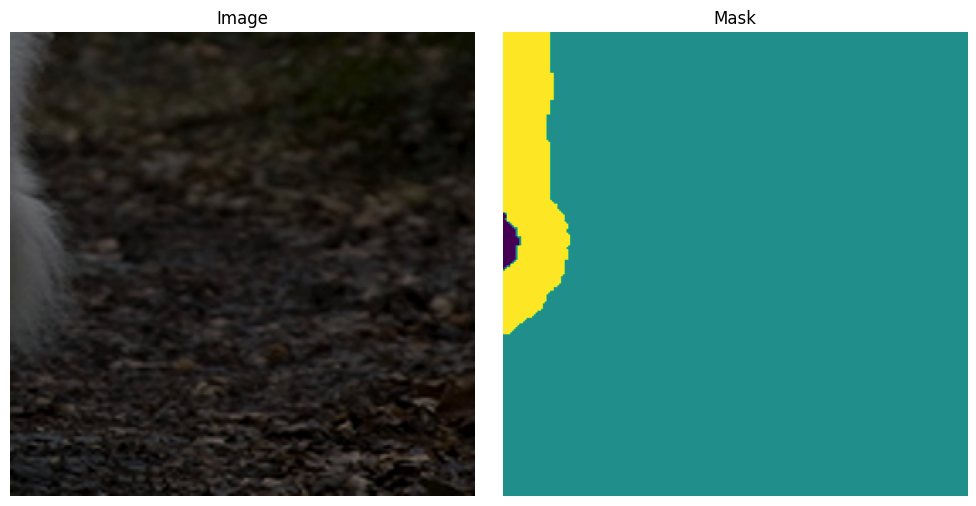

In [14]:
get_image_and_plot(55)

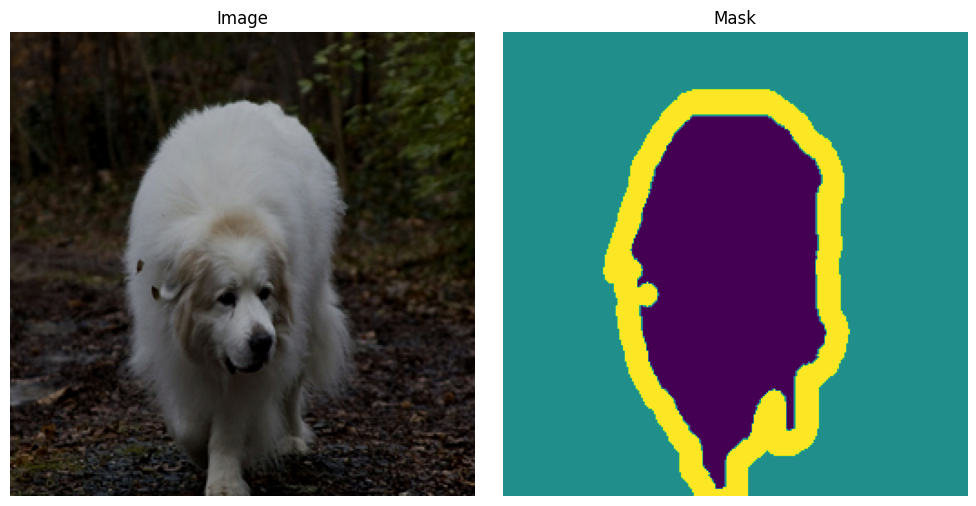

In [15]:
get_image_and_plot(55)

## Loss

In [16]:
class DiceLoss(nn.Module):
    def __init__(
        self,
        num_classes: int,
        smooth: float = 1e-6,
    ):
        super().__init__()
        self.num_classes = num_classes
        self.smooth = smooth

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        logits  : (N, C, H, W)   raw network outputs
        targets : (N, H, W)      int64 class indices in [0, C-1]
        """
        # n, c, h, w = logits.shape
        # # 1) Cross-Entropy ------------------------------------------------
        # loss_ce = self.ce_fn(logits, targets)

        # 2) Soft Dice ----------------------------------------------------
        # probabilities: (N, C, H, W)
        probs = torch.softmax(logits, dim=1)

        # one-hot targets: (N, C, H, W)
        targets_1h = F.one_hot(targets, num_classes=self.num_classes).permute(0, 3, 1, 2).float()

        # per-class Dice (vector length C)
        dims = (0, 2, 3)  # sum over batch & spatial dims
        intersection = (probs * targets_1h).sum(dims)
        union = probs.sum(dims) + targets_1h.sum(dims)
        # import pdb; pdb.set_trace()

        dice_per_class = 1 - (2 * intersection + self.smooth) / (union + self.smooth)
        dice_loss = dice_per_class.mean()

        return dice_loss

## Train

In [17]:
class LightningModule(L.LightningModule):
    def __init__(
        self,
        model: UNet,
        learning_rate: float,
        dice_loss: nn.Module,
        ce_loss: nn.Module,
        inverse_transform: transforms.Normalize,
    ) -> None:
        super().__init__()
        self.model = model
        self.learning_rate = learning_rate
        self.dice_loss = dice_loss
        self.ce_loss = ce_loss
        self.inverse_transform = inverse_transform

    def common_step(
        self, x: tuple[torch.Tensor, torch.Tensor], prefix: str, batch_idx: int
    ) -> torch.Tensor:
        image, mask = x
        out = self.model(image)
        dice_loss = self.dice_loss(out, mask)
        loss = dice_loss + self.ce_loss(out, mask)
        self.log(f"{prefix}_dice_loss", dice_loss, on_step=False, on_epoch=True)
        self.log(f"{prefix}_loss", loss, on_step=False, on_epoch=True)

        if prefix == "valid" and batch_idx == 0:
            table = wandb.Table(columns=["image", "mask", "prediction"])
            preds = out.argmax(dim=1, keepdims=True)
            for i in range(len(image)):
                # Undo your dataset-level normalization / resizing, etc.
                img_vis = self.inverse_transform(image[i])
                mask_pil = transforms.functional.to_pil_image(mask[i] / 2)
                pred_pil = transforms.functional.to_pil_image(preds[i] / 2)

                # Add one row per sample
                table.add_data(wandb.Image(img_vis), wandb.Image(mask_pil), wandb.Image(pred_pil))

            wandb.log({f"{prefix}_epoch_{self.current_epoch}": table})

        return loss

    def training_step(
        self,
        batch: tuple[torch.Tensor, torch.Tensor],
        batch_idx: int,
    ) -> torch.Tensor:
        loss = self.common_step(batch, prefix="train", batch_idx=batch_idx)

        return loss

    def validation_step(
        self,
        batch: tuple[torch.Tensor, torch.Tensor],
        batch_idx: int,
    ):
        _ = self.common_step(batch, prefix="valid", batch_idx=batch_idx)

    def configure_optimizers(
        self,
    ) -> tuple[list[torch.optim.Optimizer], list[torch.optim.lr_scheduler._LRScheduler]]:
        """
        Use a lower learning rate for the encoder (backbone) and the base
        learning rate for the rest of the network.  Keep the OneCycleLR
        scheduler, providing a separate `max_lr` for each param‑group.
        """
        # Param‑group 1: encoder / backbone ─ use lr / 10
        encoder_params = self.model.encoder.parameters()

        # Param‑group 2: everything else ─ use lr
        decoder_params = (
            list(self.model.center.parameters())
            + list(self.model.up_blocks.parameters())
            + list(self.model.seg_head.parameters())
        )

        optimizer = torch.optim.Adam(
            [
                {"params": encoder_params, "lr": self.learning_rate / 10},
                {"params": decoder_params, "lr": self.learning_rate},
            ]
        )

        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=[self.learning_rate / 10, self.learning_rate],
            total_steps=self.trainer.estimated_stepping_batches,
        )

        return [optimizer], [scheduler]


ce_loss = nn.CrossEntropyLoss()
dice_loss = DiceLoss(num_classes=NUM_CLASSES)
lightning_module = LightningModule(
    model=unet, 
    learning_rate=LEARNING_RATE, 
    dice_loss=dice_loss,
    ce_loss=ce_loss,  
    inverse_transform=inverse_transform,
)
logger = WandbLogger()

In [18]:
trainer = L.Trainer(
    max_epochs=2 if is_interactive else EPOCHS,
    accumulate_grad_batches=ACCUMULATE_GRAD_BATCHES,
    gradient_clip_val=1.0,
    precision=32,
    num_sanity_val_steps=0,
    logger=logger,
    enable_progress_bar=is_interactive,
    log_every_n_steps=100,
    limit_train_batches=10 if is_interactive else 1.0,
    limit_val_batches=3 if is_interactive else 1.0,
)
trainer.fit(lightning_module, train_dataloader, valid_dataloader)

INFO: Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO: `Trainer(limit_train_batches=1.0)` was configured so 100% of the batches per epoch will be used..
INFO: `Trainer(limit_val_batches=1.0)` was configured so 100% of the batches will be used..
/usr/local/lib/python3.11/dist-packages/lightning/pytorch/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will re

Testing purposes:

In [19]:
# images, mask = next(iter(train_dataloader))
# out = unet(images)
# dice_loss = DiceLoss(num_classes=NUM_CLASSES)
# dice_loss(out, mask)